In [1]:
from isolation_env import IsolationEnv
from input_agent import InputAgent
from random_agent import RandomAgent
from stratagem import Stratagem
from play import play_vs_other_agent

In [2]:
env = IsolationEnv()
input_agent = InputAgent()
env.action_space

Discrete(9)

Input Agents

In [3]:
#play_vs_other_agent(env, agent1=input_agent, agent2=input_agent)

Random Agents

In [4]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=RandomAgent(2), render=False)

Player 1 WON


Random Agent vs Stratagem

In [5]:
play_vs_other_agent(env, agent1=RandomAgent(1), agent2=Stratagem(2))

Player 2 WON


---
# Proyecto MATE — Isolation

Agentes implementados: **Minimax con Alpha-Beta Pruning** y **Expectimax**.  
Se experimenta con distintas funciones de evaluación y se registran resultados.

In [6]:
import time
import matplotlib.pyplot as plt
import numpy as np
from minimax_agent import MinimaxAgent, MinimaxNoPruningAgent
from expectimax_agent import ExpectimaxAgent

## 1. Framework de experimentación

Se define una función `run_games` que ejecuta N partidas entre dos agentes y registra
victorias, derrotas y duración de cada partida.

In [7]:
def run_games(env, agent1, agent2, n_games=50, verbose=False):
    """Ejecuta n_games partidas y retorna estadísticas."""
    wins_a1, wins_a2, steps_list, times_list = 0, 0, [], []

    for i in range(n_games):
        obs = env.reset()
        done = False
        winner = 0
        steps = 0
        t0 = time.time()

        while not done:
            action = agent1.next_action(obs)
            obs, _, done, winner, _ = env.step(action)
            steps += 1
            if done:
                break
            action = agent2.next_action(obs)
            obs, _, done, winner, _ = env.step(action)
            steps += 1

        elapsed = time.time() - t0
        steps_list.append(steps)
        times_list.append(elapsed)

        if winner == agent1.player:
            wins_a1 += 1
        else:
            wins_a2 += 1

        if verbose and (i + 1) % 10 == 0:
            print('  Partida {:3d}/{} — Agente1: {} | Agente2: {} | Pasos: {:.1f} | t: {:.2f}s'.format(
                i + 1, n_games, wins_a1, wins_a2, np.mean(steps_list), np.mean(times_list)))

    return {
        'wins_a1': wins_a1,
        'wins_a2': wins_a2,
        'win_rate_a1': wins_a1 / n_games,
        'avg_steps': np.mean(steps_list),
        'avg_time': np.mean(times_list),
    }


def print_results(label, results):
    print('\n=== {} ==='.format(label))
    print('  Agente 1 gana: {}/{} ({:.1f}%)'.format(
        results['wins_a1'], results['wins_a1'] + results['wins_a2'],
        results['win_rate_a1'] * 100))
    print('  Agente 2 gana: {}/{} ({:.1f}%)'.format(
        results['wins_a2'], results['wins_a1'] + results['wins_a2'],
        (1 - results['win_rate_a1']) * 100))
    print('  Pasos promedio por partida: {:.1f}'.format(results['avg_steps']))
    print('  Tiempo promedio por partida: {:.3f}s'.format(results['avg_time']))

## 2. Minimax vs Random

Primera prueba: el agente Minimax (profundidad 3, con Alpha-Beta Pruning) contra un agente que elige acciones al azar.

In [8]:
N_GAMES = 50

minimax_p1  = MinimaxAgent(player=1, depth=3)
random_p2   = RandomAgent(player=2)

print('Minimax (P1) vs Random (P2):')
res_mm_vs_rnd = run_games(env, minimax_p1, random_p2, n_games=N_GAMES, verbose=True)
print_results('Minimax (P1) vs Random (P2)', res_mm_vs_rnd)

Minimax (P1) vs Random (P2):
  Partida  10/50 — Agente1: 10 | Agente2: 0 | Pasos: 5.2 | t: 1.16s
  Partida  20/50 — Agente1: 20 | Agente2: 0 | Pasos: 5.0 | t: 1.33s
  Partida  30/50 — Agente1: 30 | Agente2: 0 | Pasos: 4.8 | t: 1.36s
  Partida  40/50 — Agente1: 40 | Agente2: 0 | Pasos: 5.0 | t: 1.36s
  Partida  50/50 — Agente1: 50 | Agente2: 0 | Pasos: 4.8 | t: 1.36s

=== Minimax (P1) vs Random (P2) ===
  Agente 1 gana: 50/50 (100.0%)
  Agente 2 gana: 0/50 (0.0%)
  Pasos promedio por partida: 4.8
  Tiempo promedio por partida: 1.356s


## 3. Expectimax vs Random

In [9]:
expectimax_p1 = ExpectimaxAgent(player=1, depth=3)
random_p2_b   = RandomAgent(player=2)

print('Expectimax (P1) vs Random (P2):')
res_em_vs_rnd = run_games(env, expectimax_p1, random_p2_b, n_games=N_GAMES, verbose=True)
print_results('Expectimax (P1) vs Random (P2)', res_em_vs_rnd)

Expectimax (P1) vs Random (P2):
  Partida  10/50 — Agente1: 8 | Agente2: 2 | Pasos: 5.6 | t: 11.70s
  Partida  20/50 — Agente1: 17 | Agente2: 3 | Pasos: 5.8 | t: 12.14s
  Partida  30/50 — Agente1: 24 | Agente2: 6 | Pasos: 6.0 | t: 11.71s
  Partida  40/50 — Agente1: 33 | Agente2: 7 | Pasos: 6.0 | t: 11.59s
  Partida  50/50 — Agente1: 41 | Agente2: 9 | Pasos: 5.9 | t: 11.56s

=== Expectimax (P1) vs Random (P2) ===
  Agente 1 gana: 41/50 (82.0%)
  Agente 2 gana: 9/50 (18.0%)
  Pasos promedio por partida: 5.9
  Tiempo promedio por partida: 11.565s


## 4. Minimax vs Expectimax

In [10]:
minimax_p1_c    = MinimaxAgent(player=1, depth=3)
expectimax_p2   = ExpectimaxAgent(player=2, depth=3)

print('Minimax (P1) vs Expectimax (P2):')
res_mm_vs_em = run_games(env, minimax_p1_c, expectimax_p2, n_games=N_GAMES, verbose=True)
print_results('Minimax (P1) vs Expectimax (P2)', res_mm_vs_em)

Minimax (P1) vs Expectimax (P2):
  Partida  10/50 — Agente1: 10 | Agente2: 0 | Pasos: 5.6 | t: 3.72s
  Partida  20/50 — Agente1: 20 | Agente2: 0 | Pasos: 5.8 | t: 3.85s
  Partida  30/50 — Agente1: 30 | Agente2: 0 | Pasos: 5.6 | t: 3.87s
  Partida  40/50 — Agente1: 39 | Agente2: 1 | Pasos: 5.6 | t: 3.77s
  Partida  50/50 — Agente1: 49 | Agente2: 1 | Pasos: 5.5 | t: 3.66s

=== Minimax (P1) vs Expectimax (P2) ===
  Agente 1 gana: 49/50 (98.0%)
  Agente 2 gana: 1/50 (2.0%)
  Pasos promedio por partida: 5.5
  Tiempo promedio por partida: 3.658s


## 4b. Roles invertidos

Se repiten los mismos tres enfrentamientos de las secciones 2, 3 y 4, pero invirtiendo qué
agente juega como Jugador 1 (empieza primero) y cuál como Jugador 2. El objetivo es verificar
si el orden de turno influye en el resultado, o si el desempeño de cada agente se mantiene
independientemente de quién mueve primero.

In [11]:
random_p1_mm = RandomAgent(player=1)
minimax_p2_b = MinimaxAgent(player=2, depth=3)

print('Random (P1) vs Minimax (P2):')
res_rnd_vs_mm = run_games(env, random_p1_mm, minimax_p2_b, n_games=N_GAMES, verbose=True)
print_results('Random (P1) vs Minimax (P2)', res_rnd_vs_mm)

Random (P1) vs Minimax (P2):
  Partida  10/50 — Agente1: 0 | Agente2: 10 | Pasos: 5.2 | t: 0.22s
  Partida  20/50 — Agente1: 0 | Agente2: 20 | Pasos: 5.2 | t: 0.30s
  Partida  30/50 — Agente1: 0 | Agente2: 30 | Pasos: 5.1 | t: 0.33s
  Partida  40/50 — Agente1: 0 | Agente2: 40 | Pasos: 5.1 | t: 0.34s
  Partida  50/50 — Agente1: 0 | Agente2: 50 | Pasos: 5.1 | t: 0.32s

=== Random (P1) vs Minimax (P2) ===
  Agente 1 gana: 0/50 (0.0%)
  Agente 2 gana: 50/50 (100.0%)
  Pasos promedio por partida: 5.1
  Tiempo promedio por partida: 0.324s


In [12]:
random_p1_em = RandomAgent(player=1)
expectimax_p2_b = ExpectimaxAgent(player=2, depth=3)

print('Random (P1) vs Expectimax (P2):')
res_rnd_vs_em = run_games(env, random_p1_em, expectimax_p2_b, n_games=N_GAMES, verbose=True)
print_results('Random (P1) vs Expectimax (P2)', res_rnd_vs_em)

Random (P1) vs Expectimax (P2):
  Partida  10/50 — Agente1: 1 | Agente2: 9 | Pasos: 5.3 | t: 1.70s
  Partida  20/50 — Agente1: 5 | Agente2: 15 | Pasos: 5.7 | t: 2.24s
  Partida  30/50 — Agente1: 6 | Agente2: 24 | Pasos: 5.7 | t: 2.61s
  Partida  40/50 — Agente1: 8 | Agente2: 32 | Pasos: 5.5 | t: 2.76s
  Partida  50/50 — Agente1: 10 | Agente2: 40 | Pasos: 5.5 | t: 2.62s

=== Random (P1) vs Expectimax (P2) ===
  Agente 1 gana: 10/50 (20.0%)
  Agente 2 gana: 40/50 (80.0%)
  Pasos promedio por partida: 5.5
  Tiempo promedio por partida: 2.625s


In [13]:
expectimax_p1_b = ExpectimaxAgent(player=1, depth=3)
minimax_p2_c    = MinimaxAgent(player=2, depth=3)

print('Expectimax (P1) vs Minimax (P2):')
res_em_vs_mm = run_games(env, expectimax_p1_b, minimax_p2_c, n_games=N_GAMES, verbose=True)
print_results('Expectimax (P1) vs Minimax (P2)', res_em_vs_mm)

Expectimax (P1) vs Minimax (P2):
  Partida  10/50 — Agente1: 0 | Agente2: 10 | Pasos: 5.0 | t: 11.64s
  Partida  20/50 — Agente1: 2 | Agente2: 18 | Pasos: 5.2 | t: 11.88s
  Partida  30/50 — Agente1: 3 | Agente2: 27 | Pasos: 5.3 | t: 11.83s
  Partida  40/50 — Agente1: 3 | Agente2: 37 | Pasos: 5.4 | t: 11.69s
  Partida  50/50 — Agente1: 4 | Agente2: 46 | Pasos: 5.4 | t: 12.00s

=== Expectimax (P1) vs Minimax (P2) ===
  Agente 1 gana: 4/50 (8.0%)
  Agente 2 gana: 46/50 (92.0%)
  Pasos promedio por partida: 5.4
  Tiempo promedio por partida: 11.995s


## 5. Impacto del Alpha-Beta Pruning

Se compara el número de nodos visitados y el tiempo de cómputo entre Minimax con y sin poda.

In [14]:
N_PRUNING = 20  # partidas para medir nodos

mm_with = MinimaxNoPruningAgent(player=1, depth=3)  # sin poda
mm_no   = MinimaxAgent(player=1, depth=3)            # con poda (Alpha-Beta)
rand_opp = RandomAgent(player=2)

nodes_with_pruning, nodes_no_pruning = [], []
times_with, times_no = [], []

for _ in range(N_PRUNING):
    obs = env.reset()
    done = False

    t0 = time.time()
    while not done:
        action = mm_no.next_action(obs)
        nodes_with_pruning.append(mm_no._nodes_visited)
        obs, _, done, _, _ = env.step(action)
        if done:
            break
        action = rand_opp.next_action(obs)
        obs, _, done, _, _ = env.step(action)
    times_with.append(time.time() - t0)

    obs = env.reset()
    done = False
    t0 = time.time()
    while not done:
        action = mm_with.next_action(obs)
        nodes_no_pruning.append(mm_with._nodes_visited)
        obs, _, done, _, _ = env.step(action)
        if done:
            break
        action = rand_opp.next_action(obs)
        obs, _, done, _, _ = env.step(action)
    times_no.append(time.time() - t0)

print('Nodos por jugada (Alpha-Beta):  avg={:.1f}  max={}'.format(
    np.mean(nodes_with_pruning), max(nodes_with_pruning)))
print('Nodos por jugada (sin poda):    avg={:.1f}  max={}'.format(
    np.mean(nodes_no_pruning), max(nodes_no_pruning)))
print('Reduccion de nodos: {:.1f}%'.format(
    100 * (1 - np.mean(nodes_with_pruning) / np.mean(nodes_no_pruning))))
print('Tiempo por partida (Alpha-Beta): {:.3f}s'.format(np.mean(times_with)))
print('Tiempo por partida (sin poda):   {:.3f}s'.format(np.mean(times_no)))

Nodos por jugada (Alpha-Beta):  avg=3464.0  max=21806
Nodos por jugada (sin poda):    avg=37619.4  max=170372
Reduccion de nodos: 90.8%
Tiempo por partida (Alpha-Beta): 1.215s
Tiempo por partida (sin poda):   12.782s


C:\Users\santi\AppData\Local\Temp\ipykernel_4812\2189629089.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([nodes_with_pruning, nodes_no_pruning],


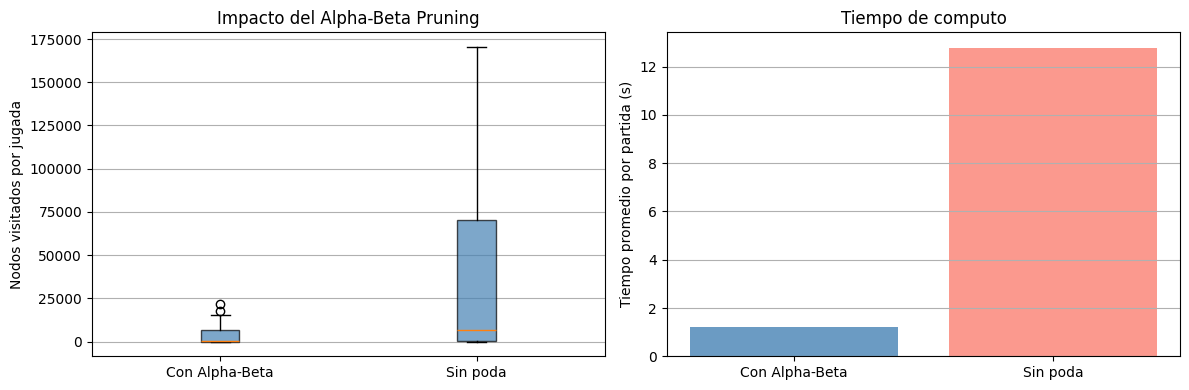

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.boxplot([nodes_with_pruning, nodes_no_pruning],
           labels=['Con Alpha-Beta', 'Sin poda'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel('Nodos visitados por jugada')
ax.set_title('Impacto del Alpha-Beta Pruning')
ax.grid(True, axis='y')

ax = axes[1]
ax.bar(['Con Alpha-Beta', 'Sin poda'], [np.mean(times_with), np.mean(times_no)],
       color=['steelblue', 'salmon'], alpha=0.8)
ax.set_ylabel('Tiempo promedio por partida (s)')
ax.set_title('Tiempo de computo')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pruning_analysis.png', dpi=150)
plt.show()

## 6. Comparación de funciones de evaluación

Se evalúan tres variantes del agente Minimax con diferentes funciones de evaluación:
- **Mobility only**: diferencia de movimientos disponibles
- **Reachability only**: diferencia de celdas alcanzables (BFS)
- **Combined** (default): 2×reachability + 1×mobility + 0.5×centrality

In [16]:
from board import Board
from collections import deque


class MinimaxMobilityOnly(MinimaxAgent):
    """Solo diferencia de movimientos disponibles."""
    def heuristic_utility(self, board):
        mob_me = len(board.get_possible_actions(self.player))
        mob_op = len(board.get_possible_actions(3 - self.player))
        return float(mob_me - mob_op)


class MinimaxReachOnly(MinimaxAgent):
    """Solo diferencia de celdas alcanzables."""
    def heuristic_utility(self, board):
        return float(self._reachable_cells(board, self.player) -
                     self._reachable_cells(board, 3 - self.player))


eval_variants = [
    ('Mobility only',     MinimaxMobilityOnly(player=1, depth=3)),
    ('Reachability only', MinimaxReachOnly(player=1, depth=3)),
    ('Combined',          MinimaxAgent(player=1, depth=3)),
]

eval_results = {}
for label, agent in eval_variants:
    print('Probando:', label)
    res = run_games(env, agent, RandomAgent(player=2), n_games=30)
    eval_results[label] = res
    print('  Win rate vs Random: {:.1f}%'.format(res['win_rate_a1'] * 100))

Probando: Mobility only
  Win rate vs Random: 100.0%
Probando: Reachability only
  Win rate vs Random: 96.7%
Probando: Combined
  Win rate vs Random: 100.0%


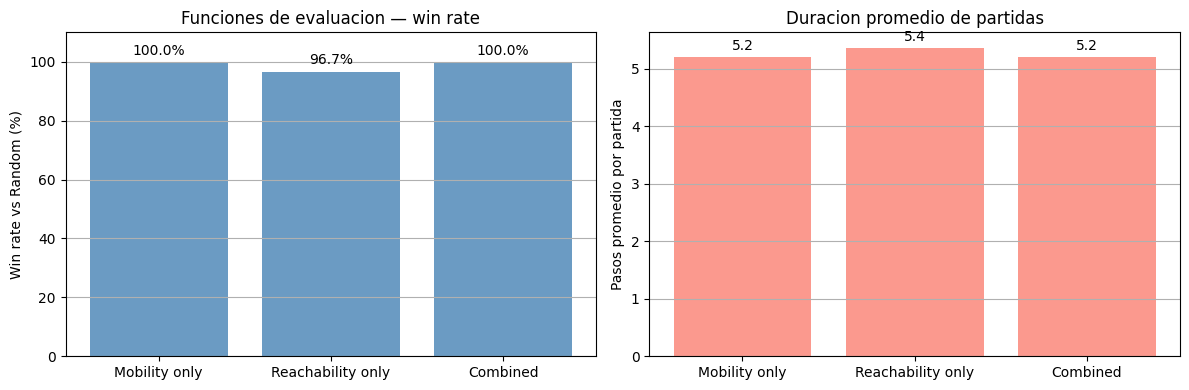

In [17]:
labels_ev = list(eval_results.keys())
win_rates  = [eval_results[l]['win_rate_a1'] * 100 for l in labels_ev]
avg_steps  = [eval_results[l]['avg_steps'] for l in labels_ev]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(labels_ev, win_rates, color='steelblue', alpha=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('Win rate vs Random (%)')
ax.set_title('Funciones de evaluacion — win rate')
ax.set_ylim(0, 110)
ax.grid(True, axis='y')

ax = axes[1]
bars2 = ax.bar(labels_ev, avg_steps, color='salmon', alpha=0.8)
ax.bar_label(bars2, fmt='%.1f', padding=3)
ax.set_ylabel('Pasos promedio por partida')
ax.set_title('Duracion promedio de partidas')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eval_functions.png', dpi=150)
plt.show()

## 6b. Minimax y Expectimax vs Stratagem

`Stratagem` es un agente con su propia lógica de tipo minimax y heurística propia (ver
`stratagem.py`), a diferencia de `RandomAgent`, que juega al azar. Se lo usa como rival más
exigente para contrastar contra los resultados obtenidos contra Random. Se prueban ambos
agentes propios (Minimax y Expectimax) en los dos órdenes de turno posibles.

In [19]:
N_STRAT = 20  # Stratagem tiene su propia búsqueda tipo minimax; se reduce el numero de partidas por el costo de tiempo

print('Minimax (P1) vs Stratagem (P2):')
res_mm_vs_strat = run_games(env, MinimaxAgent(player=1, depth=3), Stratagem(2), n_games=N_STRAT, verbose=True)
print_results('Minimax (P1) vs Stratagem (P2)', res_mm_vs_strat)

Minimax (P1) vs Stratagem (P2):
  Partida  10/20 — Agente1: 7 | Agente2: 3 | Pasos: 5.1 | t: 1.99s
  Partida  20/20 — Agente1: 15 | Agente2: 5 | Pasos: 4.7 | t: 2.06s

=== Minimax (P1) vs Stratagem (P2) ===
  Agente 1 gana: 15/20 (75.0%)
  Agente 2 gana: 5/20 (25.0%)
  Pasos promedio por partida: 4.7
  Tiempo promedio por partida: 2.055s


In [20]:
print('Stratagem (P1) vs Minimax (P2):')
res_strat_vs_mm = run_games(env, Stratagem(1), MinimaxAgent(player=2, depth=3), n_games=N_STRAT, verbose=True)
print_results('Stratagem (P1) vs Minimax (P2)', res_strat_vs_mm)

Stratagem (P1) vs Minimax (P2):
  Partida  10/20 — Agente1: 7 | Agente2: 3 | Pasos: 5.3 | t: 3.24s
  Partida  20/20 — Agente1: 14 | Agente2: 6 | Pasos: 5.1 | t: 3.43s

=== Stratagem (P1) vs Minimax (P2) ===
  Agente 1 gana: 14/20 (70.0%)
  Agente 2 gana: 6/20 (30.0%)
  Pasos promedio por partida: 5.1
  Tiempo promedio por partida: 3.427s


In [21]:
print('Expectimax (P1) vs Stratagem (P2):')
res_em_vs_strat = run_games(env, ExpectimaxAgent(player=1, depth=3), Stratagem(2), n_games=N_STRAT, verbose=True)
print_results('Expectimax (P1) vs Stratagem (P2)', res_em_vs_strat)

Expectimax (P1) vs Stratagem (P2):
  Partida  10/20 — Agente1: 2 | Agente2: 8 | Pasos: 5.2 | t: 11.39s
  Partida  20/20 — Agente1: 5 | Agente2: 15 | Pasos: 5.2 | t: 11.57s

=== Expectimax (P1) vs Stratagem (P2) ===
  Agente 1 gana: 5/20 (25.0%)
  Agente 2 gana: 15/20 (75.0%)
  Pasos promedio por partida: 5.2
  Tiempo promedio por partida: 11.575s


In [22]:
print('Stratagem (P1) vs Expectimax (P2):')
res_strat_vs_em = run_games(env, Stratagem(1), ExpectimaxAgent(player=2, depth=3), n_games=N_STRAT, verbose=True)
print_results('Stratagem (P1) vs Expectimax (P2)', res_strat_vs_em)

Stratagem (P1) vs Expectimax (P2):
  Partida  10/20 — Agente1: 8 | Agente2: 2 | Pasos: 5.0 | t: 6.10s
  Partida  20/20 — Agente1: 15 | Agente2: 5 | Pasos: 5.5 | t: 6.06s

=== Stratagem (P1) vs Expectimax (P2) ===
  Agente 1 gana: 15/20 (75.0%)
  Agente 2 gana: 5/20 (25.0%)
  Pasos promedio por partida: 5.5
  Tiempo promedio por partida: 6.061s


## 7. Resumen general de resultados

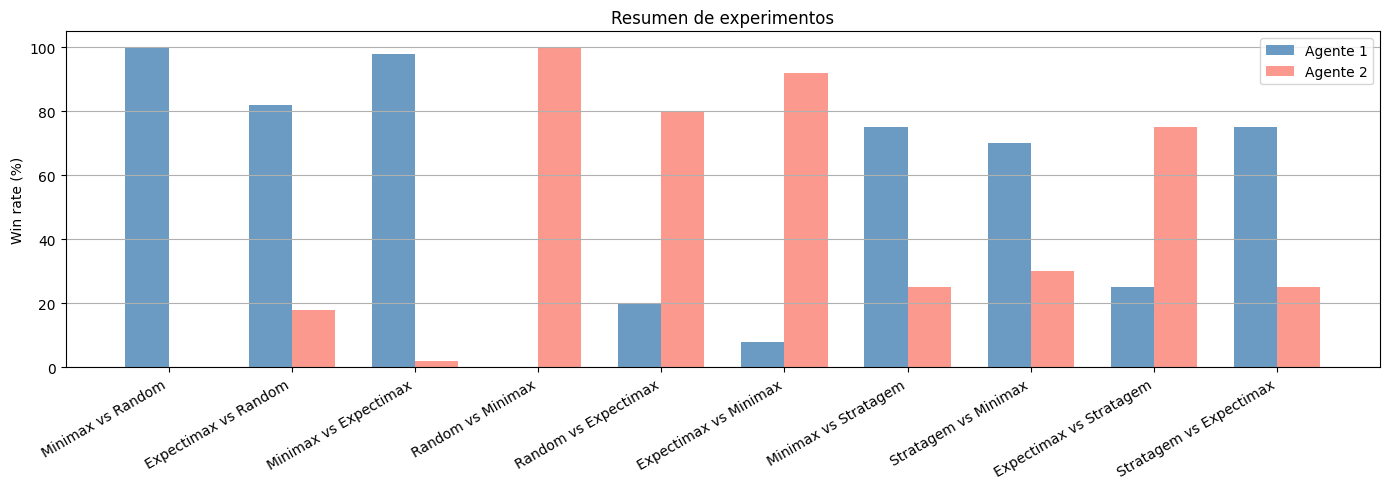


Tabla resumen:
Experimento                      Win A1 (%)   Win A2 (%)   Pasos prom
----------------------------------------------------------------------
Minimax vs Random                     100.0          0.0          4.8
Expectimax vs Random                   82.0         18.0          5.9
Minimax vs Expectimax                  98.0          2.0          5.5
Random vs Minimax                       0.0        100.0          5.1
Random vs Expectimax                   20.0         80.0          5.5
Expectimax vs Minimax                   8.0         92.0          5.4
Minimax vs Stratagem                   75.0         25.0          4.7
Stratagem vs Minimax                   70.0         30.0          5.1
Expectimax vs Stratagem                25.0         75.0          5.2
Stratagem vs Expectimax                75.0         25.0          5.5


In [23]:
experiments = [
    ('Minimax vs Random',        res_mm_vs_rnd),
    ('Expectimax vs Random',     res_em_vs_rnd),
    ('Minimax vs Expectimax',    res_mm_vs_em),
    ('Random vs Minimax',        res_rnd_vs_mm),
    ('Random vs Expectimax',     res_rnd_vs_em),
    ('Expectimax vs Minimax',    res_em_vs_mm),
    ('Minimax vs Stratagem',     res_mm_vs_strat),
    ('Stratagem vs Minimax',     res_strat_vs_mm),
    ('Expectimax vs Stratagem',  res_em_vs_strat),
    ('Stratagem vs Expectimax',  res_strat_vs_em),
]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(experiments))
width = 0.35
exp_labels = [e[0] for e in experiments]
wr_a1 = [e[1]['win_rate_a1'] * 100 for e in experiments]
wr_a2 = [(1 - e[1]['win_rate_a1']) * 100 for e in experiments]

ax.bar(x - width/2, wr_a1, width, label='Agente 1', color='steelblue', alpha=0.8)
ax.bar(x + width/2, wr_a2, width, label='Agente 2', color='salmon', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(exp_labels, rotation=30, ha='right')
ax.set_ylabel('Win rate (%)')
ax.set_title('Resumen de experimentos')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('summary.png', dpi=150)
plt.show()

print('\nTabla resumen:')
print('{:30s} {:>12} {:>12} {:>12}'.format('Experimento', 'Win A1 (%)', 'Win A2 (%)', 'Pasos prom'))
print('-' * 70)
for name, res in experiments:
    print('{:30s} {:>12.1f} {:>12.1f} {:>12.1f}'.format(
        name, res['win_rate_a1']*100, (1-res['win_rate_a1'])*100, res['avg_steps']))